# Plot saved `jul11a_paper_fastest` posteriors

Load the saved joint posterior checkpoints and their saved debias arrays, then regenerate only the debiased Hubble diagram and predicted luminosity plot. This notebook does not call `hubble_fit` or resume any sampling.

In [1]:
from pathlib import Path

import numpy as np
from IPython.display import FileLink, IFrame, display
%load_ext autoreload
%autoreload 2

repo_root = Path.cwd().resolve()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent

prefix = "jul11a_paper_fastest"
z_range = (0.44, 3.16)
cosmo_models = ["Flatw0waCDM"]
spectra_fit_csv = repo_root / "results/data/spectra_data_all.csv"
light_curve_h5 = repo_root / "results/data/lc_data_all.h5"
checkpoint_dir = repo_root / "results/hubble_posteriors" / prefix
checkpoints = {
    model: checkpoint_dir / f"posteriors_{model}_joint_fastest_all_z0p44_3p16_2d.h5"
    for model in cosmo_models
}

missing_checkpoints = [path for path in checkpoints.values() if not path.is_file()]
if missing_checkpoints:
    raise FileNotFoundError(f"Cannot plot: missing {prefix} checkpoint(s): {missing_checkpoints}")

missing_inputs = [path for path in (spectra_fit_csv, light_curve_h5) if not path.is_file()]
if missing_inputs:
    raise FileNotFoundError(f"Missing required plotting input(s): {missing_inputs}")

checkpoints

{'Flatw0waCDM': PosixPath('/home/dutra/dev/qvc3/results/hubble_posteriors/jul11a_paper_fastest/posteriors_Flatw0waCDM_joint_fastest_all_z0p44_3p16_2d.h5')}

In [2]:
from qvc.hubble.hubble_utils import load_chains

required_keys = {
    "flat_samples",
    "dmi_posterior_median",
    "dmi_posterior_sigma",
    "dmi_selection_sigma_posterior_median",
    "object_id_fit_selection",
}
expected_parameter_counts = {"FlatLambdaCDM": 7, "Flatw0waCDM": 9}
checkpoint_payloads = {}
checkpoint_summary = []
for model, checkpoint in checkpoints.items():
    payload = load_chains(checkpoint)
    missing_keys = required_keys.difference(payload)
    if missing_keys:
        raise RuntimeError(f"Cannot plot {model}: {checkpoint} is missing {sorted(missing_keys)}")

    flat_samples = np.asarray(payload["flat_samples"])
    selection_ids = np.asarray(payload["object_id_fit_selection"])
    expected_ndim = expected_parameter_counts[model]
    if flat_samples.ndim != 2 or flat_samples.shape[1] != expected_ndim:
        raise RuntimeError(f"Cannot plot {model}: incompatible flat_samples shape {flat_samples.shape}")
    if selection_ids.size == 0:
        raise RuntimeError(f"Cannot plot {model}: checkpoint has an empty fit selection")
    for key in ("dmi_posterior_median", "dmi_posterior_sigma", "dmi_selection_sigma_posterior_median"):
        if np.asarray(payload[key]).shape != (selection_ids.size,):
            raise RuntimeError(f"Cannot plot {model}: {key} does not match the saved fit selection")

    checkpoint_payloads[model] = payload
    checkpoint_summary.append({"model": model, "samples": flat_samples.shape[0], "fit_selection": selection_ids.size})

checkpoint_summary

[{'model': 'Flatw0waCDM', 'samples': 544, 'fit_selection': 8089}]

In [3]:
from qvc.hubble.hubble_fit import restrict_agn_to_resume_replot_sample, z_pivot_agn
from qvc.hubble.hubble_utils import load_agn_data, load_pantheon_data

df_pantheon, _, _, _ = load_pantheon_data()
df_agn, _ = load_agn_data(
    light_curve_h5,
    apply_cut=True,
    spectra_fit_csv=[str(spectra_fit_csv)],
    z_range=z_range,
    plot_path=repo_root / "plots/hubble" / prefix,
    cut_report_path=repo_root / "plots/hubble" / prefix / "cut_summary.txt",
)

df_agn_by_model = {
    model: restrict_agn_to_resume_replot_sample(df_agn, str(checkpoint))
    for model, checkpoint in checkpoints.items()
}
[(model, len(frame)) for model, frame in df_agn_by_model.items()]

CPU Num Cores: 30
Loading Pantheon+ supernova data...
Loading SN covariance matrix...
Cholesky factorization successful. Selected SNe: 1657 / 1701 (kept 1657; dropped 44).
Applied column compatibility shim: log_mbh->LOGMBH, log_mbh_err->LOGMBH_ERR
Number of quasars loaded: 23456
Populating spectra fit data from: ['/home/dutra/dev/qvc3/results/data/spectra_data_all.csv']
Loading spectra fit CSV (1/1): /home/dutra/dev/qvc3/results/data/spectra_data_all.csv
Length of merged DataFrame: 23456
Using f_host_2500_psf from PSF posterior reconstruction as the primary host fraction; completeness reads f_host_2500_psf explicitly.
Filled 748 NaN f_host_2500 values with 0.0
Computed light_curve_n_points from: variability_n_points_g, variability_n_points_i, variability_n_points_r excluding bands: u


/home/dutra/.conda/envs/jaxcpu4/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Suberlak-style fit [precut M_2500] for sigma_uv using M_2500 at lambda_RF=2500 A (B fixed=-0.479, N=23330, chi2_red=0.917): A=-0.8996±0.0017, C=0.0808±0.0010 (Suberlak 0.1180), D=0.0756±0.0031 (Suberlak 0.1180), sigma_int=0.0761±0.0015 dex
Suberlak-style fit [precut M_2500] for tau_uv_rf using M_2500 at lambda_RF=2500 A (B fixed=0.170, N=23330, chi2_red=0.883): A=2.6786±0.0040, C=-0.0181±0.0022 (Suberlak 0.0350), D=0.1077±0.0067 (Suberlak 0.1410), sigma_int=0.2592±0.0025 dex
Suberlak-style fit [precut M_i_Wu_z2] for sigma_uv using M_i_Wu_z2 at lambda_RF=2500 A (B fixed=-0.479, N=23148, chi2_red=0.917): A=-0.8988±0.0016, C=0.0825±0.0010 (Suberlak 0.1180), D=0.0908±0.0030 (Suberlak 0.1180), sigma_int=0.0753±0.0015 dex
Suberlak-style fit [precut M_i_Wu_z2] for tau_uv_rf using M_i_Wu_z2 at lambda_RF=2500 A (B fixed=0.170, N=23148, chi2_red=0.883): A=2.6811±0.0041, C=-0.0157±0.0023 (Suberlak 0.0350), D=0.1082±0.0076 (Suberlak 0.1410), sigma_int=0.2583±0.0022 dex


/home/dutra/dev/qvc3/src/qvc/hubble/hubble_plotting.py:3090: RuntimeWarning: overflow encountered in power
  upper[finite] = np.clip(np.power(10.0, log_value[finite] + log_err[finite]) - value[finite], 0.0, None)


Sigma/tau LS identity grid written to: /home/dutra/dev/qvc3/plots/hubble/jul11a_paper_fastest/diagnostics/sigma_tau_ls_identity_precut.pdf
  sigma finite rows used: 23,456
  tau finite rows used: 23,456
Matched 426 out of 23456 objects to CSC3 catalog.
Number of quasars with 0 < z <= 1.0: 5009
Number of quasars with z > 3: 504
Highest redshift quasar: 4.91943087058762


/home/dutra/.conda/envs/jaxcpu4/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Number of quasars with 0 < z <= 1.0: 1916
Number of dropped quasars with 0 < z <= 1.0: 3093
Number of quasars with z > 3: 129

Total number of objects removed by all cuts: 15095
Final number of quasars: 8361
Suberlak-style fit [postcut M_2500] for sigma_uv using M_2500 at lambda_RF=2500 A (B fixed=-0.479, N=8345, chi2_red=0.916): A=-0.9073±0.0027, C=0.0843±0.0018 (Suberlak 0.1180), D=0.0913±0.0051 (Suberlak 0.1180), sigma_int=0.0400±0.0044 dex
Suberlak-style fit [postcut M_2500] for tau_uv_rf using M_2500 at lambda_RF=2500 A (B fixed=0.170, N=8345, chi2_red=0.903): A=2.6024±0.0059, C=-0.0292±0.0036 (Suberlak 0.0350), D=0.1125±0.0113 (Suberlak 0.1410), sigma_int=0.2168±0.0038 dex
Suberlak-style fit [postcut M_i_Wu_z2] for sigma_uv using M_i_Wu_z2 at lambda_RF=2500 A (B fixed=-0.479, N=8308, chi2_red=0.914): A=-0.9089±0.0027, C=0.0847±0.0016 (Suberlak 0.1180), D=0.1030±0.0052 (Suberlak 0.1180), sigma_int=0.0389±0.0047 dex
Suberlak-style fit [postcut M_i_Wu_z2] for tau_uv_rf using M_i_Wu_

[('Flatw0waCDM', 8089)]

Using linear-z bins: [0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8 2.  2.2 2.4 2.6 2.8 3.  3.2 3.4]
Plotting binned AGN (linear z) at: [0.5 0.7 0.9 1.1 1.3 1.5 1.7 1.9 2.1 2.3 2.5 2.7 2.9 3.1]
	mask_in: [ True  True  True  True  True  True  True  True  True  True  True  True
  True  True]
Plotting binned AGN (linear z) at: [0.5 0.7 0.9 1.1 1.3 1.5 1.7 1.9 2.1 2.3 2.5 2.7 2.9 3.1]
	mask_out: [False False False False False False False False False False False False
 False False]


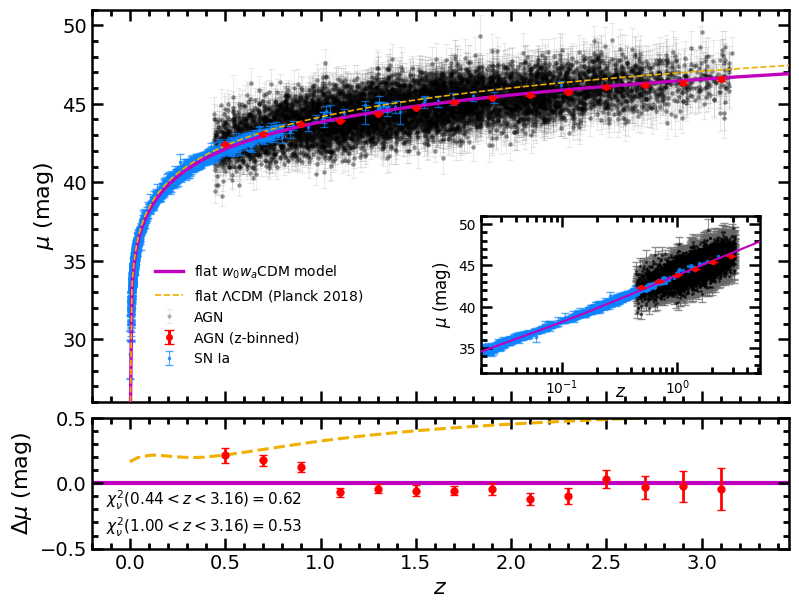

Saved Hubble error-budget summary to /home/dutra/dev/qvc3/plots/hubble/jul11a_paper_fastest/Flatw0waCDM_joint_fastest_all_z0p44_3p16_2d/diagnostics/hubble_error_budget_summary_debiased.csv
Saved per-object Hubble error budget to /home/dutra/dev/qvc3/plots/hubble/jul11a_paper_fastest/Flatw0waCDM_joint_fastest_all_z0p44_3p16_2d/diagnostics/hubble_error_budget_per_object_debiased.csv
Hubble error budget: chi2_full=0.324, chi2_no_intrinsic=0.620, chi2_full_plus_sigma_dmi=0.324, chi2_no_intrinsic_plus_sigma_dmi=0.620, chi2_no_predM=0.768, median_predM_err=0.867 mag, median_predM_sigma=1.068 mag, median_predM_tau=0.575 mag, median_intrinsic=0.736 mag, median_sigma_dmi=0.012 mag, residual_rms=0.650 mag
Residuals saved to /home/dutra/dev/qvc3/plots/hubble/jul11a_paper_fastest/Flatw0waCDM_joint_fastest_all_z0p44_3p16_2d/residuals.csv
x_log_ref range with errors: -2.379 to 1.590


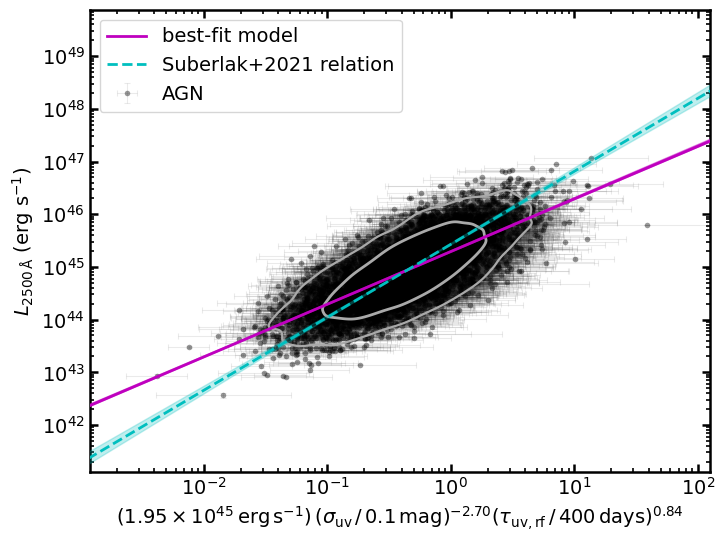

In [4]:
from qvc.hubble.hubble_completeness_refactored import COMPLETENESS_FHOST_COL, make_dm_function
from qvc.hubble.hubble_plotting import plot_hubble, plot_predicted_L2500_vs_sigmahat

plot_names = ["hubble_diagram_debiased.pdf", "predicted_L2500_vs_fullcorr_band_debiased.pdf"]
plot_paths = {}
model = "Flatw0waCDM"
payload = checkpoint_payloads[model]
df_plot = df_agn_by_model[model]
dmi_values = np.asarray(payload["dmi_posterior_median"], dtype=float)
dmi_sigma = np.asarray(payload["dmi_posterior_sigma"], dtype=float)
dmi_selection_sigma = np.asarray(payload["dmi_selection_sigma_posterior_median"], dtype=float)
dm_interp = make_dm_function(
    df_plot["apparent_mag_2500"].to_numpy(dtype=float),
    df_plot["z"].to_numpy(dtype=float),
    dmi_values,
    f_host_2500_psf=df_plot[COMPLETENESS_FHOST_COL].to_numpy(dtype=float),
    alpha_lambda=df_plot["alpha_lambda"].to_numpy(dtype=float),
)
plot_path = repo_root / "plots/hubble" / prefix / f"{model}_joint_fastest_all_z0p44_3p16_2d"
plot_hubble(
    np.asarray(payload["flat_samples"]),
    df_plot,
    df_pantheon,
    cosmo_model=model,
    z_pivot_agn=z_pivot_agn,
    debias=True,
    dm_interp=dm_interp,
    dmi_values=dmi_values,
    dmi_sigma=dmi_sigma,
    dmi_selection_sigma=dmi_selection_sigma,
    plot_path=plot_path,
    filename=plot_names[0],
    verbose=False,
    z_range=z_range,
    show=True
)
plot_predicted_L2500_vs_sigmahat(
    np.asarray(payload["flat_samples"]),
    df_plot,
    cosmo_model=model,
    z_pivot_agn=z_pivot_agn,
    debias=True,
    dm_interp=dm_interp,
    dmi_values=dmi_values,
    dmi_selection_sigma=dmi_selection_sigma,
    plot_path=plot_path,
    show_residuals=False,
    z_range=z_range,
    show=True
)
plot_paths[model] = [plot_path / name for name in plot_names]
